In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Configuración visual
plt.style.use('ggplot')
sns.set_theme(style="darkgrid", palette="deep")

# 1. Cargamos el dataset
df = pd.read_csv('/content/sample_data/walmart_ml_ready.csv')

print(f"✅ ¡Dataset cargado en la nube con éxito! Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
display(df.head(5))


KeyboardInterrupt: 

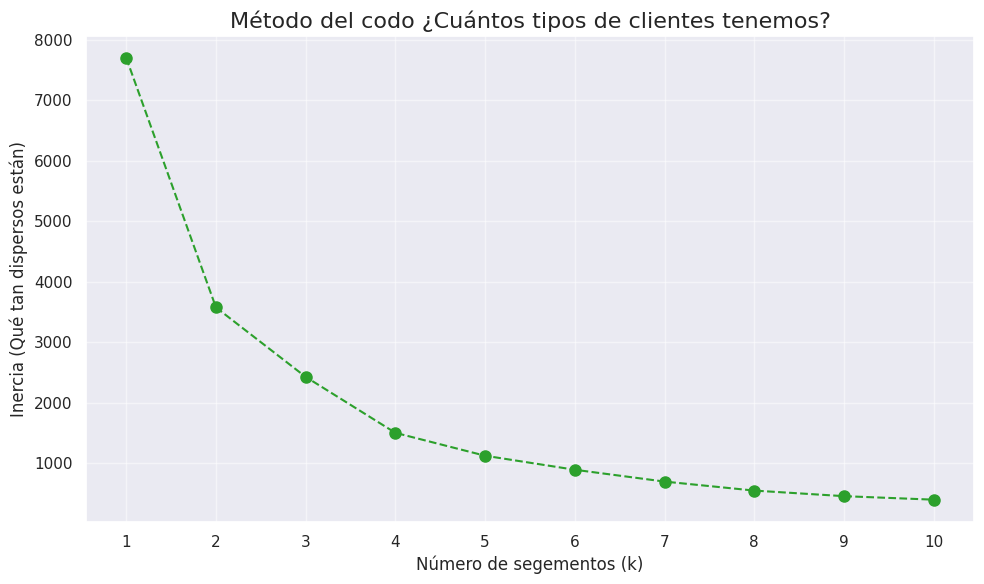

In [ ]:
#================================================
# PASO 1: PREPARACIÓN DE DATOS Y MÉTODO DEL CODO
#================================================
# 1. Calculamos el ingreso por transacción (Por si acaso no venia en la tabla)
df['ingresos'] = df['quantity_sold'] * df['unit_price']

# 2. Agrupamos para crear "Perfil del Cliente"
df_clientes = df.groupby('customer_id').agg(
    frecuencia=('customer_id', 'count'), # Cuántas veces compró
    gasto_total=('ingresos', 'sum') # Cuánto dinero dejó en total
).reset_index()

# 3. Escalamos los datos
scaler = StandardScaler()
clientes_escalados = scaler.fit_transform(df_clientes[['frecuencia', 'gasto_total']])

# 4. El método del codo (Buscando el número mágico de grupos)
inercia = []
rango_k = range(1, 11)

for k in rango_k:
    # Entrenamos un mini-modelo de prueba para k=1, k=2... hasta K=10
    kmeans_prueba = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_prueba.fit(clientes_escalados)
    inercia.append(kmeans_prueba.inertia_)

# 5. Graficamos los resultados
plt.figure(figsize=(10, 6))
plt.plot(rango_k, inercia, marker='o', linestyle='--', color='#2ca02c', markersize=8)
plt.title('Método del codo ¿Cuántos tipos de clientes tenemos?', fontsize=16)
plt.ylabel('Inercia (Qué tan dispersos están)', fontsize=12)
plt.xlabel('Número de segementos (k)', fontsize=12)
plt.xticks(rango_k)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

## Analicemos el codo:

Si vemos en k=1 a k=2 la línea cae en picada de 7800 a 3500 aproximadamente. De k=2 a k=3 sigue cayendo fuerte, y en K=4 es donde la curva hace el "doblez" claro y apartir de k=5 ya casi no baja.

Ese doblez en K=4 no esta gritandoel número mágico. Y hace todo el sentido del negocio ya que podemos dividir a los clientes en 4 niveles clásicos *Platinum, Gold, Silver y Bronze.*

Ahora que ya sabemos que queremos 4 grupos, vamos a decirle al algoritmo que lo haga, agrupe a los clientes y dibuje como se ven esos clusters en la vida real.

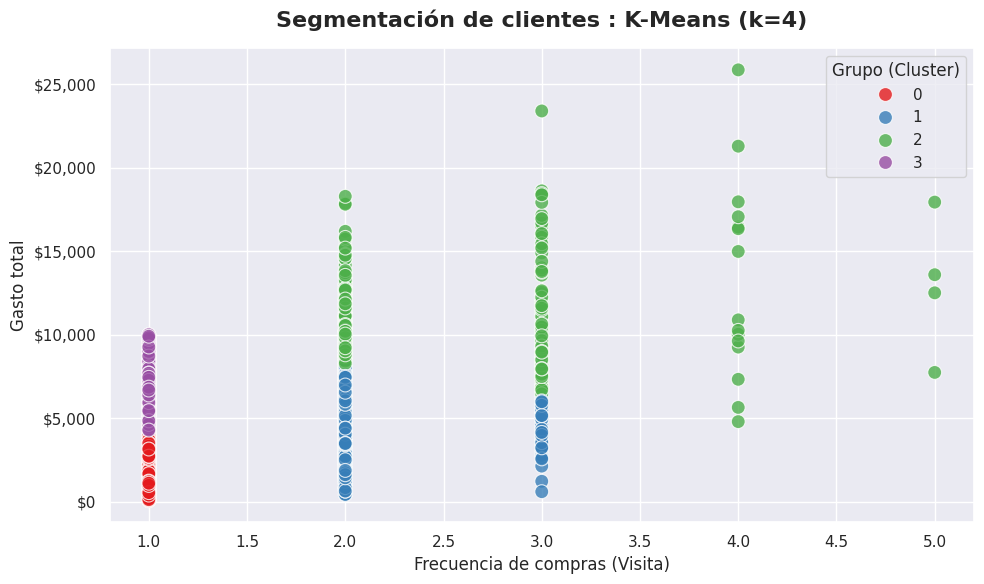

🧾 RESUMEN DE LOS SEGMENTOS ENCONTRADOS


,clientes_totales,gasto_promedio,frecuencia_promedio
cluster,,,
2,320,10932.39,2.44
3,833,6235.80,1.00
1,647,4564.36,2.07
0,2048,1766.44,1.00


In [ ]:
#==============================================
# PASO 2: ENTRENANDO AL MODELO K-MEANS CON K=4
#==============================================

# 1. Instanciamos el modelo con nuestro número mágico
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')

# 2. Entrenamos y asignamos a cada cliente su grupo directamente
df_clientes['cluster'] = kmeans.fit_predict(clientes_escalados)

# 3. Vamos a ver como quedaron agrupados visualmente
plt.figure(figsize=(10,6))
ax = sns.scatterplot(
    data=df_clientes,
    x='frecuencia',
    y='gasto_total',
    hue='cluster',
    palette='Set1',
    s=100,
    alpha=0.8
)
plt.title('Segmentación de clientes : K-Means (k=4)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Frecuencia de compras (Visita)', fontsize=12)
plt.ylabel('Gasto total', fontsize=12)

#Formatear el ej Y como moneda ($)
import matplotlib.ticker as ticker
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
plt.legend(title='Grupo (Cluster)')
plt.tight_layout()
plt.show()

# Veamos el promedio de cada grupo para ponerles nombre
resumen_clusters = df_clientes.groupby('cluster').agg(
    clientes_totales=('customer_id', 'count'),
    gasto_promedio=('gasto_total', 'mean'),
    frecuencia_promedio=('frecuencia', 'mean')
).round(2).sort_values(by='gasto_promedio', ascending=False)

print("🧾 RESUMEN DE LOS SEGMENTOS ENCONTRADOS")
display(resumen_clusters)

## Interpretación:

- 🟢 **Cluster 2 = PLATINUM:** Son poquitos, (320 clientes), pero tienen el gasto promedio mas fuerte (10,932.39) y la *frecuencia mas alta con 2.44.* A estos podriamos mandarle un regalo en su cumpleaños.
- 🟣 **Cluster 3 = GOLD:** Tienen un gasto altisimo (6,235.80), pero.... tienen una *frecuencia de 1.00.* Es decir vinieron una vez compraron medio waltmart y no regresaron. ¡Aqui podria entrar una campaña de retargeting!
- 🔵 **Cluester 1 = SILVER:** Gastan moderado (4,564.36) pero son super leales *frecuencia de 2.07.* Son los clientes de "cada quincena." Sostienen el negocio a largo plazo.
- 🔴 **Cluster 0 = BRONZE:** Es el volumen mas grande (2048 clientes.) Vinieron una vez *frecuencia 1.00* y gastaron poquito (1,766.44). Compraron algo de paso y se fueron.

#### Siguiente paso:
"Bauticemos" a esos números (0,1,2,3) con sus nombres verdaderos, Platinum, Gold, Silver y Bronze.

In [ ]:
#=======================================
# PASO 3. ETIQUETADO Y PREPARACIÓN FINAL
#=======================================

# 1. Creamos un diccionario para traducir el número al Nivel de Lealtad ML
nombres_segementos = {
    2: 'Platinum (VIP)',
    3: 'Gold (High Ticket)',
    1: 'Silver (Leales)',
    0: 'Bronze (Casuales)'
}

# 2. Aplicamos el nombre al Dataframe Original
df_clientes['segmento_ml'] = df_clientes['cluster'].map(nombres_segementos)

# 3. Veamos cómo quedó nuestra tabla final ya masticada para el cliente
print("✅ Clientes segmentados exitosamente. Vista previa:")
display(df_clientes[['customer_id', 'frecuencia', 'gasto_total', 'segmento_ml']].head())

# 4. Exportamos este resultado para el Dashboard
df_clientes.to_csv('clientes_segementados.csv', index=False)
print("\n ✅🧾✅ Archivo 'clientes_segmentados.csv' guardado. ¡Listo para el Dashboard!" )

✅ Clientes segmentados exitosamente. Vista previa:


,customer_id,frecuencia,gasto_total,segmento_ml
0,1001,1,990.27,Bronze (Casuales)
1,1002,1,4941.87,Gold (High Ticket)
2,1003,1,710.03,Bronze (Casuales)
3,1004,1,6879.05,Gold (High Ticket)
4,1006,1,6372.40,Gold (High Ticket)



 ✅🧾✅ Archivo 'clientes_segmentados.csv' guardado. ¡Listo para el Dashboard!
